In [3]:
# Diving into RNNs ( designed based as mentioned here : {sutskever et al. 2011} https://icml.cc/2011/papers/524_icmlpaper.pdf )

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [4]:
words = open("names.txt", 'r').read().splitlines()

In [5]:
len(words)

32033

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
print(itos)

vocab_size = len(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [9]:
# building the dataset
block_size = 3 # context length

def build_dataset(words):
    
    X, Y = [], []
    for w in words:
    
        # print(w)
        context = [0] * block_size
        for ch in w +'.' :
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [12]:
# MLP revisited

# Changes:

# S. 1
# bais_2 * 0 -> at init, we don't want to add random values to logits
# weight_2 * 0.01 -> to scale down on W2, proportionally sacles down logits on init
# which get rids of higher false confidence

# S. 2
# bais_1 * 0.01 -> to bring hpreact closer to 0, while having some entropy (* 0 is also fine)
# weight_1 * 0.1 (or any > 0) -> to bring hpreact closer to 0

# how do we come up with these 0, 0.1, 0.01 etc.?
# See below

# Weight_1 * kaiming_init -> to make sure std after the first activation is not too shrung or wide (close to 1)

# why not weight also 0??
#
n_embed = 10 # the dim of the character embedding vector
n_hidden = 200 # the num of neuron in hidded layer

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed),             generator=g)
W1 = torch.randn((n_embed * block_size, n_hidded), generator=g) * (5/3)/((n_embed * block_size)**0.5) #0.2
# b1 = torch.randn(n_hidded,                         generator=g) * 0.01      bnbais is being used instead
W2 = torch.randn((n_hidded, vocab_size),           generator=g) * 0.01
b2 = torch.randn(vocab_size,                       generator=g) * 0

# S. 3
bngain = torch.ones((1, n_hidden))
bnbais = torch.zeros((1, n_hidden))
# S. 4
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbais] # [C, W1, W2, b1, b2, bngain, bnbais]
sum(p.nelement() for p in parameters) # num parameters in total
for p in parameters:
    p.requires_grad = True

tensor(0.0147) tensor(0.9933)
tensor(0.0020) tensor(0.9895)


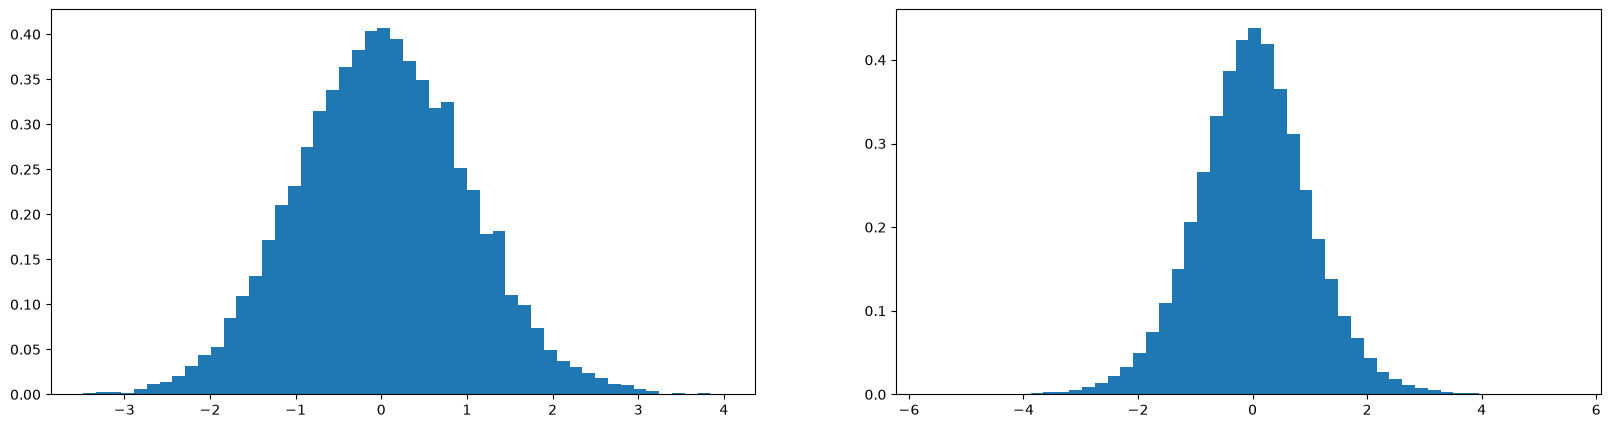

In [13]:
# how do we come up with these 0, 0.1, 0.01 etc.?

# what we want - we want the st. d. to remain relatively same before or after activations to
# preserve the disribution while remaining a gaussian

# if we * w with 
    # 1. > 1 ->  st. d. increases
    # 2. < 1 -> st. d. decreases
    # as we want a decrease we mult by a scalar < 1. but what exactly??

# mathematically, it is seen that we need to divide the w, by sqrt of fan_in (number of inputs)

# the scaling factor for init have been deeply studied and the most often cited paper is by
# Kaiming He, .. where they study on CNN for ReLU. (https://arxiv.org/pdf/1502.01852)

# pytorch has a function for this as well:
    # torch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='tanh or ..')
    # https://docs.pytorch.org/docs/2.14/nn.init.html#torch.nn.init.kaiming_normal_

    # gain for tanh is - 5/3

x = torch.randn(1000, 10) # std -> approx 1
# as fan_in = 10
w = torch.randn(10, 200) / 10**0.5
y = x @ w                 # std -> without scaling - > 1 (relative)
                          # std -> with scaling w - approx 1
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [14]:
# for details of implementation, see Micrograd2.ipynb

# S. 3
    # (hpreact * mean) / std -> batch norm, to make the distribution standard normal
    # bngain * hpreact + bnbias -> so that during backprop the dist. can scale and shift

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    #forward pass
    emb = C[Xb] # embed the char into vectors
    embcat = emb.view(emb.shape[0], -1) # concat the vectors

    # linear layer
    hpreact = embcat @ W1 #+ b1 we use bnbais instead # hidded layer pre-activation

    # batch norm layer -----------------------------------------------------
    # S. 4
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    # S. 3
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbais # batch norm 
    # S. 4
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani 
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    #------------------------------------------------------------------------

    # non-linearity
    h = torch.tanh(hpreact)   # [-1, 1] due to tanh (hidden layer)
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000: 3.2856
  10000/ 200000: 2.1340
  20000/ 200000: 2.1373
  30000/ 200000: 2.2285
  40000/ 200000: 2.0133
  50000/ 200000: 1.7307
  60000/ 200000: 2.2741
  70000/ 200000: 2.2340
  80000/ 200000: 2.3828
  90000/ 200000: 2.0722
 100000/ 200000: 2.2072
 110000/ 200000: 2.1703
 120000/ 200000: 2.2788
 130000/ 200000: 1.8803
 140000/ 200000: 1.7875
 150000/ 200000: 2.1805
 160000/ 200000: 1.9339
 170000/ 200000: 1.9587
 180000/ 200000: 2.1038
 190000/ 200000: 2.0363


In [15]:
# S 1. -ve log probability of 1/27

# -torch.tensor(1/27.0).log() # expected init loss

# one way to get uniform prob is having the initial logits to be all same i.e. all 0 (prefered)
# or other integer

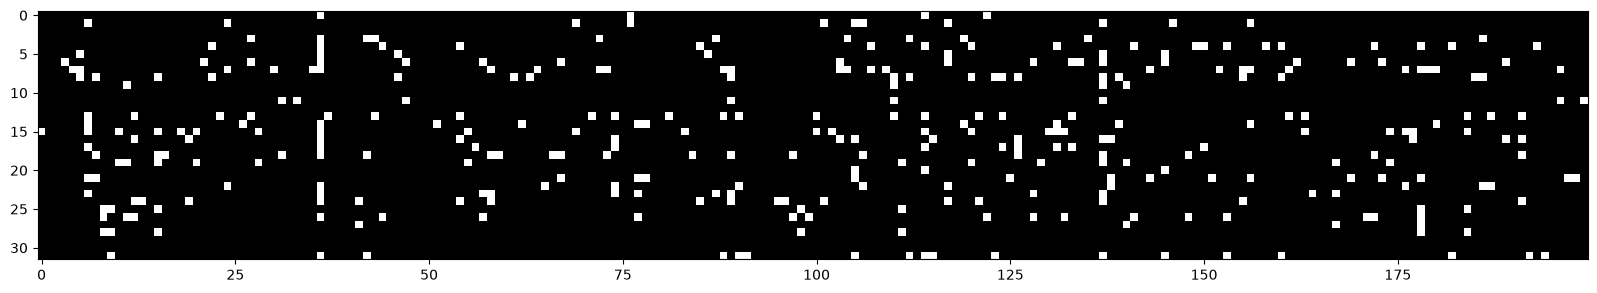

In [16]:
# S 2. shows how may neurons are > 0.99 (white for true; black for false)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

# if there is any column( of 200 ) that is all white, 
# then it is a dead neuron and will never learn

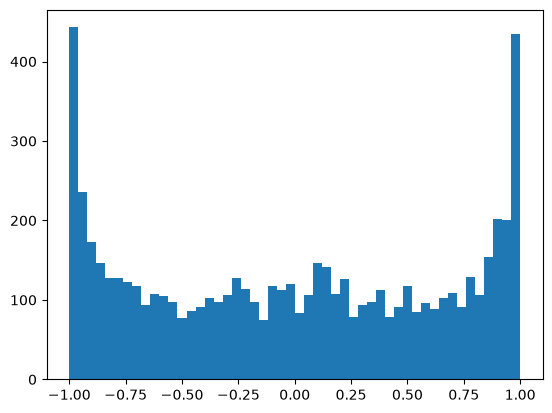

In [17]:
# S 2.
plt.hist(h.view(-1).tolist(), 50); # too many +1 and -1, why? see below

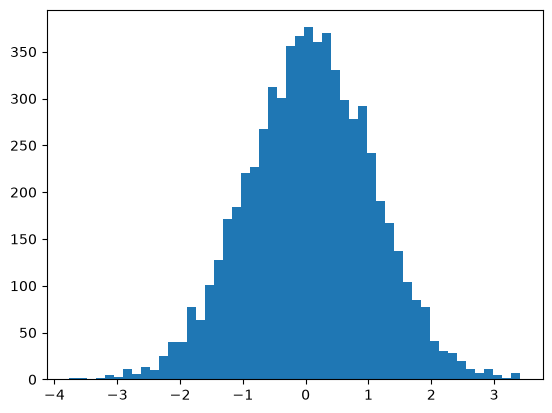

In [59]:
# S 2.
plt.hist(hpreact.view(-1).tolist(), 50); # too many pre-activations higher or lower than 0

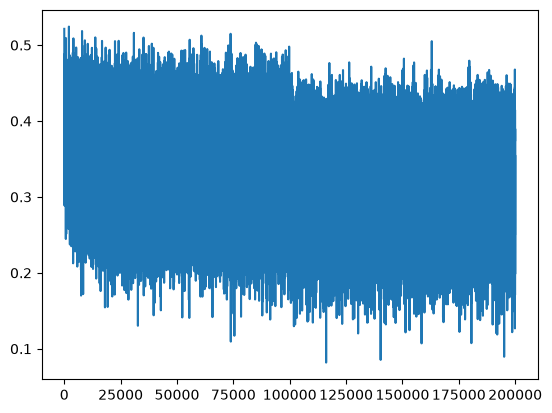

In [37]:
plt.plot(lossi)

In [ ]:
# S. 4

# calibrate the batch norm at the end of training 

# Using the running mean instead of an additional step

# with torch.no_grad():
#     # pass the training set through
#     emb = C[Xtr]
#     embcat = emb.view(emb.shape[0], -1)
#     hpreact = embcat @ W1 + b1
#     # measure the mean and st. d. of the entire training set 
#     bnmean = hpreact.mean(0, keepdim=True)
#     bnstd = hpreact.std(0, keepdim=True)
    

In [19]:
@torch.no_grad() # disables gradient tracking

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]  # split will be used to index
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 #+ b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True))/ hpreact.std(0, keepdim=True) + bnbais # batch norm 
    # S. 4
    hpreact = bngain * (hpreact - bnmean_running)/ bnstd_running + bnbais # batch norm ( accepts single data point as well)
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size) 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0657238960266113
val 2.109696865081787


In [21]:
# sampling 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # all .'s
    while True:
        emb = C[torch.tensor([context])] # (1, block_size , d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmarrqubfiqsiffigrrigtatlannahssacerzontrachrisht.
trquifferrnishchrishdnsleggbbh.
mardissquqynzshlvightviebquwrntrystefrishmfrreklitraclef.
frightgtlffrriffallsasmbrychussadnmelosozswyllyssiasjifrender.
sadnnyx.
qothsishranshyndra.
stly.
nrahmfushnnoxrrishbbdn.
ffzersithgbrichlidgnyctorlynnerlendruquinchmetrishshantezambrendriyah.
frishrish.
trishnneksbrinnziclez.
s.
stleomignnyernsclynnezysharliellahnnarryssayfyannahmbrryadntyhksorallsty.
frsxwrnnyxirraz.
stzy.
rvellnbxlntiyah.
strn.
frnnygmavzhnndarrsdabrikeerdrvishmardissmfrrighttleyghthar.
lek.
trghgfplyndly.


In [ ]:
# STARTING LOSS:
#     train: 2.124538
#     val: 2.16819

# Scritnization (part 3 begins)

# 1. Initialization :
    # as we can see the begining loss is 27.--, which is way to high. So, we can infer that
    # model is not properly configured at init.
    # how to calculate expected loss, see S 1.
    # as there is no training done, we can expect that equal probability will be assigned to any 
    # of the 27 char.
    
    # benifit of having better initilization:
        # more time spent on actual optimization of network, as seen above (lower loss)

# LOSS AFTER fixing this:
#     train: 2.07
#     val : 2.13

In [ ]:
# 2. the activated values of hidden layer on INITILIAZATION:
    # as seen in above histograms, most of the activated values are either 1 or -1.
    # and this creates a problem during back prop

    # to understand this we need to see the backward pass through tanh
    # :- (1 - tanh(x)**2) * out.grad
    #     now if we see the local grad - if tanh(x) is 1 or -1, the local grad becomes 0.
    #     i.e. the gradient of this node and any previous now will be 0 henceforth.
    #     this is due to 1 and -1 being in the flat tails for the tanh graph

    # prop of tanh for gradient:
    #     during Back prob - a tanh node can either have no effect on incomming out.grad if
    #         tanh(x) == 0
    #         or 
    #     can make it small we i.e. if tanh(x) = [-1, 0) U (0, 1] {grad becomes 0 at 1 ot -1)

    # we do not want to many +1 or -1 on init activation, and no dead neuron
    # ino our case, we have many +- 1's 

# LOSS AFTER fixing this:
#     train: 2.0355
#     val: 2.1026

In [1]:
# 3. Batch Normalization (https://arxiv.org/pdf/1502.03167 : paper)
    # Idea: if we want the hidden state to be a normal gaussian, then just standarsize them to a Gaussian normal distribution as 
    # that operation is easily backpropagatable.

    # problem: not very good loss, because we want the hidden activation to be roughly gaussian only at initialization.
    # but we don't want forced gaussian, we want the spread to have the capability to more around( br flexible) so that even the 
    # distribution itself be optimized as we optimize the network i.e. it can be diffuse, be sharp, have diff tanh linearity etc.

    # Soln: as the simple normalization won't meet all the requirements, the paper goes 1 step further and adds scale and shift functionality
    # on top of simple standardization.
    #                             = a * ((x * mean)/std_) + b
    #                             a: scaling term  (bngain)
    #                             b: shifting term (bnbias)

    # this stability comes at a cost:
    # previously, even while taking the batch, processing of individual logits was independent, but now as seen in batch norm,
    # after every iteration we normalize the pre-activation layer using the batch mean and std, every individual logit is now a function
    # of all the logits of that batch ( not independent anymore)

    # but when used in practice, this cost becomes desirable. As it kind of regularizes the logits by introducing some entropy (noise)
    # based on the batch that was sampled randomly. Which makes it harder for the neural net to overfit these examples

    # But, although this entropy is desirable. The influence of batch on individuals still introduces lot of uncertainity and 
    # bugs to the network. This has led to the use of other normalization techniques that do not influence individual logits, eg. 
    # layer norm, group norm etc.

                                    
# LOSS AFTER using this:
#     train: 2.0668
#     val: 2.1024844
    # Though the loss is a little worse (cause the network is very small), the network is more scalable 

# 4. Testing a batch norm net
    # This leads to another problem:
    # Now that the neural net expects batches even in testing, how do we test a single test case?

    # The paper proposes the following: have a step after training that calculates and sets the bnmean and bnstd for a single time over
    # the training set

    # As this adds an extra step, alternatively we can also keep a running mean and std while training

# The loss we get is identical, but now the model also supports better predictions for single data point